# Guía para el procesamiento de genomas de *Thiotrichales* 

## Objetivo
El propósito de esta guía es explica paso a paso cómo limpiar procesar los datos de genomas de *Thiotrichales* (archivos .fasta). El pipeline esta diseñado para transformar archivos crudos en una tabla final y compatible con el siguiente  [script](https://github.com/ecoevolab/thiotrichales_genomics/blob/main/grafica/grafica.R).

La meta es filtrar los datos necesarios que sirvan de input para recrear la siguiente imagen:


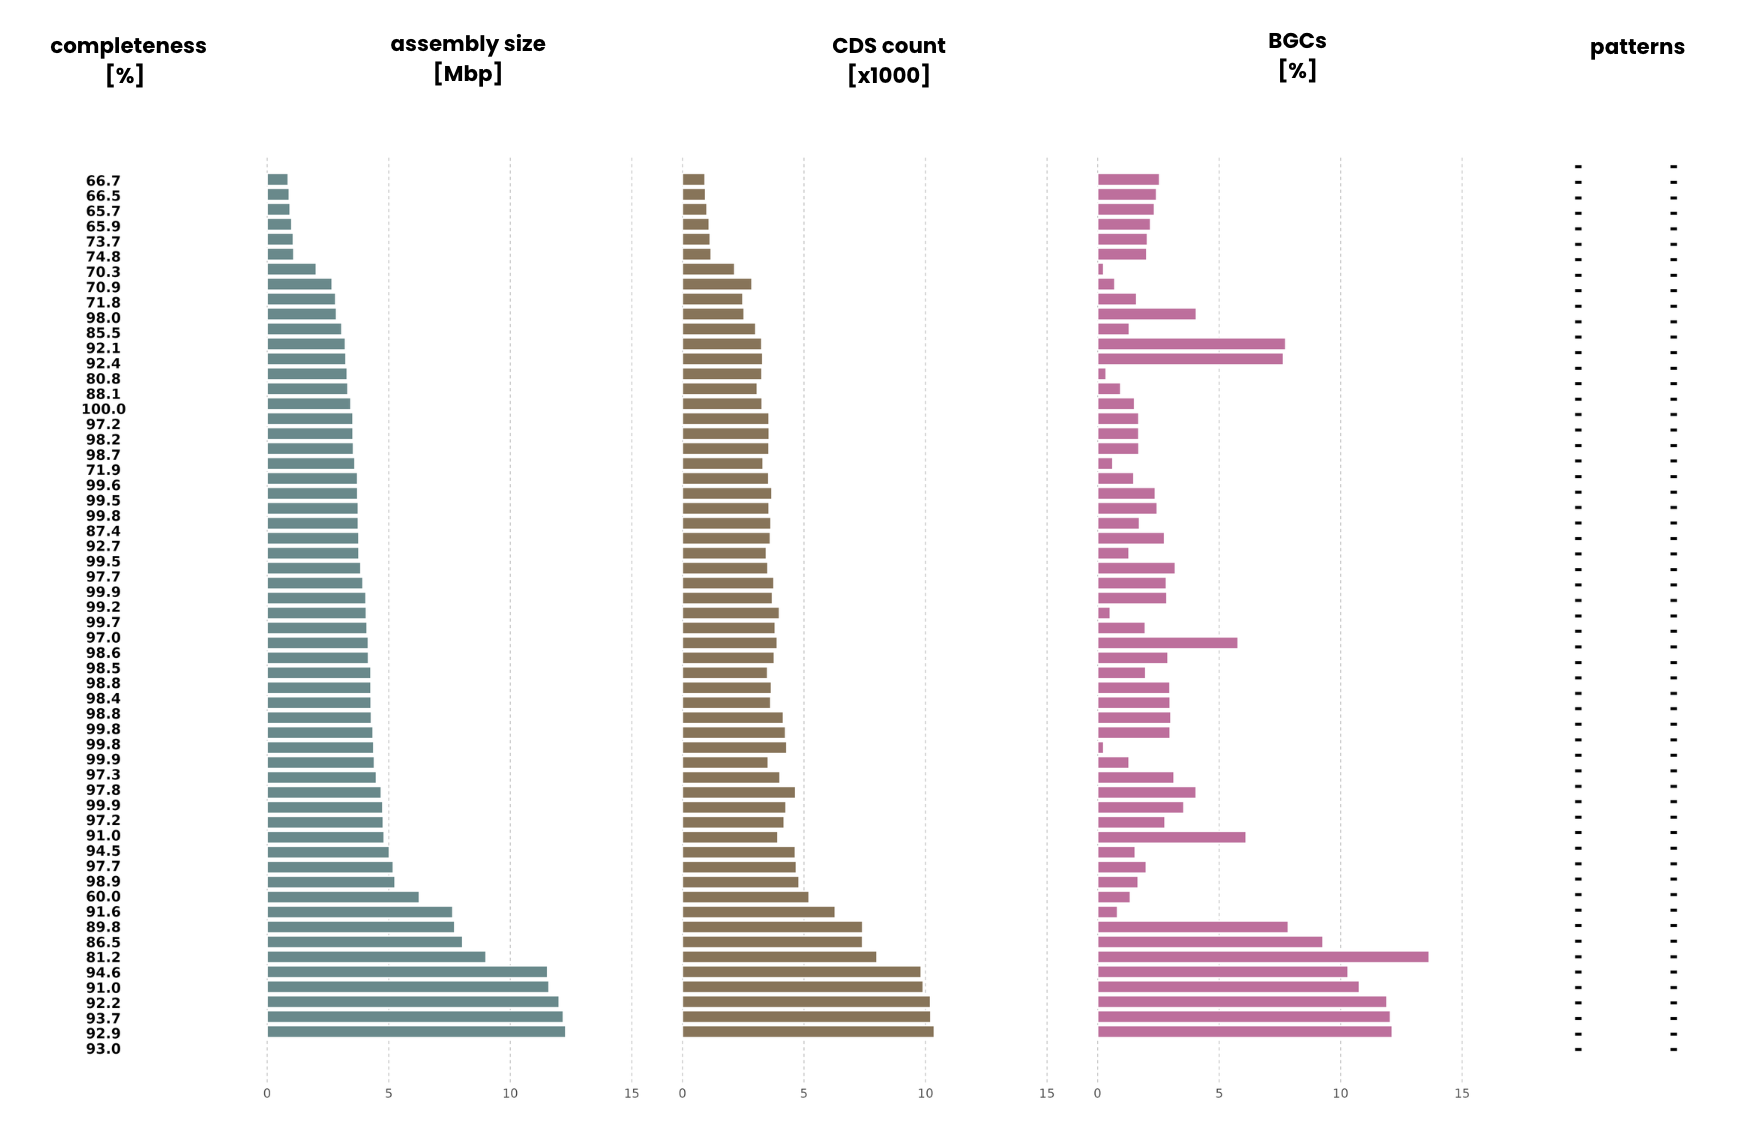


## Metodología (Cómo obtener cada columna)
Para que los datos sean compatibles con la gráfica, se necesita procesar cada genoma con las siguientes herramientas:

1. **CheckM v1.2.2:** esta herramienta nos permite saber la completitud del genoma, asi cómo la contaminación y el tamaño del genoma bacter.

   **Columnas generadas:** Completeness [%] y Assembly size [Mbp].

2. **Prokka (tmb agregar version):**  Realiza una anotación de características funcionales dentro de un genoma bacteriano (genes, proteínas, etc).

   **Columna generada:** CDS count [x1000].

3. **antiSMASH:** Herramienta especializada en la identificación de grupos de genes biosinteticos (BGCs) de metabilitos secuendarios en bacteria.

   **Columna generada:** BGCs[%].

4. **eggNOG + HMMER:** el primero es una base de datos que nos proporciona grupos de genes ortólogos, mientras que el segundo es una herramienta bioinformatica que utiliza modelos ocultos de Markov, para alinear y encontrar patrones de dominios proteícos especificos.

   **Columna generada:** patterns.



## Interpretación de la tabla final
Para facilitar el análisis de la gráfica, en esta sección se define el significado de cada columna obtenida:

- **Completeness [%]:** Indica el procentaje de completitud del genoma.
- **Assembly size [MBp]:** Es el tamaño total del genoma en Megabases
- **CDS count [x1000]:** Numero de pares de bases **PENDIENTE**
- **BGCs [%]:** Es el número de pares de bases que ocupa los Biosintetic gene cluster en el genoma, reflejado en porcentaje.
- **Paterns:** Esta compuesta por dos columnas:
  1. la primera indica si estan presentes (+) o ausentes (-) todos los genes del cluster de división celular de bacterias modelo (AGREGAR LOS GENES)
  2. La segunda columna indica si hay alguna duplicación (+) en el set de genes del elongosoma (mreD, mrdA, and rodZ) o se mantienen en su forma simple (-).

## Procesamiento de datos
### Sección 1: Control de calidad con CheckM 

El primer paso es evaluar la calidad de los genomas que tenemos. [CheckM](https://github.com/Ecogenomics/CheckM/wiki) proporciona un conjunto de herramientas para evaluar la calidad de los genomas, proporciona estimaciones de la integridad y contaminación. 


#### 1.1 ¿Cómo ejecturar CheckM?

Debido a que el análisis de múltiples genomas es una tarea que require una alta capacidad computacional, utilizamos un cluster de alto rendimiento (HPC) que utiliza el gestor de recursos [SLURM](https://slurm.schedmd.com/documentation.html) para administrar y distribuir las tareas en nodos de procesamiento.

Para ejecutar **CheckM v1.2.2** (que estaba previamente instalado) utilizamos el siguiente script:

NOTA: este script tiene que pegarse en un editor de texto como `nano`.



```bash
#!/bin/bash
#SBATCH --job-name=checkm_thiotrichales     #nombre del job
#SBATCH --output=checkm_thiotrichales.log   #donde se va a guardar el proceso
#SBATCH --error=checkm_thiotrichales.error  #donde se van a guardar los errores
#SBATCH --nodes=1                           #nodos que se van a usar
#SBATCH --ntask=10                          #procesadores para trabajar en paralelo (CPUs)
#SBATCH --mem=32G                           #cuanta memoria RAM se va a usar
#SBATCH --time=120:00:00                    #tiempo limite de ejecucion

date
echo "====Starting checkm Analysis===="

eval "$(conda shell.bash hook)"  
 
conda activate checkm                      #se activa el entorno donde esta instalado CheckM

INPUT_DIR="ruta/donde/estan/los/genomas/de/input"
OUTPUT_DIR="ruta/donde/se/van/a/guardar/los/resultados"

mkdir -p "$OUTPUT_DIR"
checkm lineage_wf \
    -x fna \
    "$INPUT_DIR" \
    "$OUTPUT_DIR" \
    -t 10 \
    --tab_table \
    -f "$OUTPUT_DIR/resultados_checkm.tsv"

echo "==== Analisis terminado con exito ===="
date
```

Una vez terminado solo debe mandarse a la cola de procesamiento, para hacerlo se puede hacer como el siguiente comando:

```bash
sbatch nombre_del_job.sh 
```

#### 1.2 Filtrado de calidad y selección de genomas

Luego de obtener el output de checkm, el siguiente paso es filtrar los genomas, es decir, elegir aquellos que tengan la mejor calidad y con menos contaminación. Para este trabajo, utilizamos los siguientes umbrales (los cuales son arbitrarios para el tipo de estudio que se este queriendo realizar).

- **Completitud (Completeness)** > 50%
- **Contaminación (Contamination)** < 30%

Para realizar esto, lo primero es entrar a la carpeta de resultados de checkm, seguidamente entrar a la subcarpeta `storage` y  visualizar el archivo `bin_stats_ext.tsv`, que se verá algo así: 


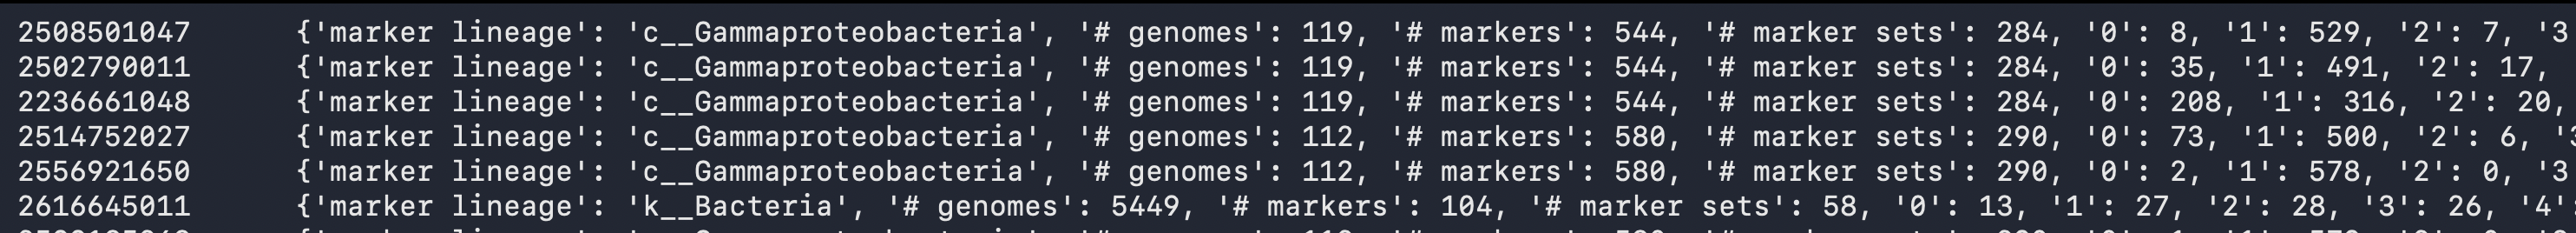

Las columnas que nos interesan son las siguientes:
- **Completeness**
- **Contamination**
- **Assembly size**

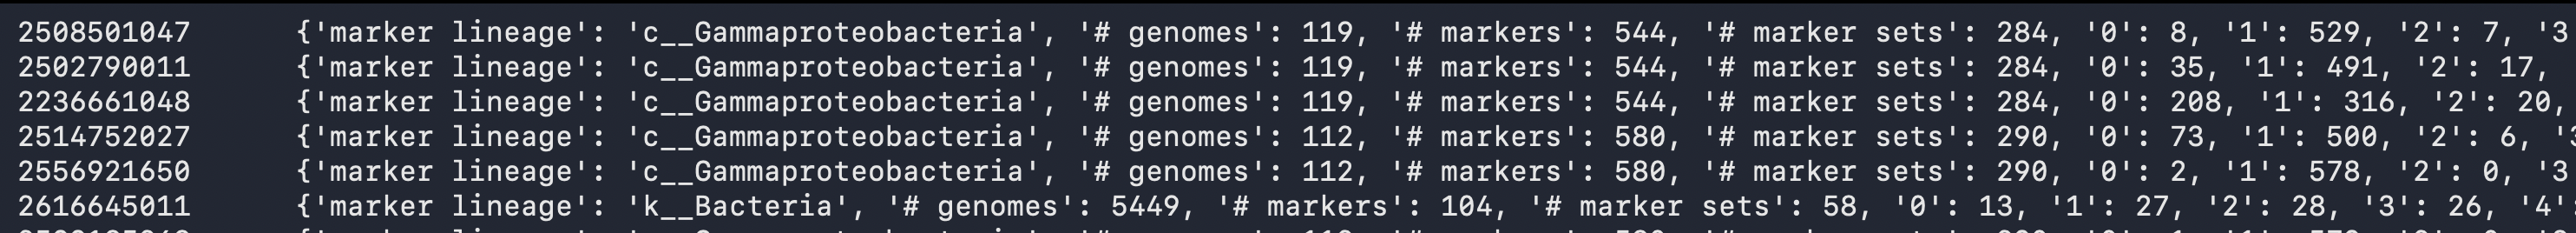

Una estrategia eficiente para filtrar la columna Completeness consiste en pre-seleccionar aquellos genomas que cumplen con el requisito de completitud (>50%). Es decir, obtener primero los IDs de estas muestras y luego filtrar los datos como conjunto. Lo podemos hacer mediante el siguiente comando.

```bash
awk -F "[:,]" '$22 > 50 && $24 < 30 {print $1, $22, $24}' bin_stats_ext.tsv > ID.txt
```

Una vez que tenemos el archivo ID.txt, dentro de este habra tres columnas, la primera contendra el ID de los genomas, la segunda el procentaje de Completeness y la tercera el porcentaje de Contaminación. Se verá de la siguiente forma.